In [1]:
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.cm as cm

from astropy.table import unique, Table, join

from numpy.lib.recfunctions import structured_to_unstructured
import fitsio

In [2]:
tbl_data = Table.read("data/qnet_ensemble_guadalupe.csv")

In [3]:
def calc_entropy(confidence):
    H = confidence * np.log(confidence)
    H = np.where(confidence == 0, 0, H)
    return -np.sum(H, axis=1)


In [4]:
confs = structured_to_unstructured(np.asarray(tbl_data["C_NOT", "C_QSO_LZ", "C_QSO_HZ"]))
entropy = calc_entropy(confs)

/tmp/ipykernel_1359039/885452469.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence)
/tmp/ipykernel_1359039/885452469.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence)


In [5]:
tbl_data.add_column(entropy, name="ENTROPY")
tbl_data.sort("ENTROPY", reverse=True)

tbl_data

TARGETID,TILEID,EXPID,C_NOT,C_QSO_LZ,C_QSO_HZ,BMU,ENTROPY
int64,int64,int64,float64,float64,float64,int64,float64
39633054049765137,1791,88873,0.34,0.33,0.33,740,1.0985126170507196
39627703741055635,1083,91171,0.335,0.34,0.325,1185,1.0984368565761047
39627777833441573,1835,93282,0.35,0.33,0.32,878,1.0979153802869457
39627753825244495,1841,94986,0.36,0.32,0.32,971,1.097032390352067
39627709650829350,1120,91063,0.345,0.305,0.35,1113,1.0967607591718467
39632971321314289,2162,88532,0.355,0.305,0.34,879,1.0966168618656336
39633100581374253,1734,89271,0.35,0.3,0.35,374,1.0960673284468554
39627969836092800,2986,97429,0.36,0.345,0.295,418,1.095077273664015
39627946830336921,1848,94622,0.295,0.375,0.33,417,1.0937997131510127


In [6]:
tbl_tiles = unique(tbl_data, ["TARGETID", "TILEID"])

# Get the unique targetids, and the number of times each appears in the input table
unique_tids, n_occur = np.unique(tbl_tiles["TARGETID"], return_counts=True)

# Get the targetids that appear more than once and then filter
# the table to only keep the targetids that have more than one tileid. 
tids_multi = unique_tids[n_occur > 1] 
tbl_tiles = tbl_tiles[np.isin(tbl_tiles["TARGETID"], tids_multi)]

In [7]:
percentile_cut = 15
bmu_counts = np.bincount(tbl_data["BMU"], minlength=np.max(tbl_data["BMU"]))
good_bmu = bmu_counts > np.percentile(bmu_counts, percentile_cut)
good_idcs = good_bmu[tbl_data["BMU"]]

tbl_reduced = tbl_data[good_idcs]
tbl_reduced

TARGETID,TILEID,EXPID,C_NOT,C_QSO_LZ,C_QSO_HZ,BMU,ENTROPY
int64,int64,int64,float64,float64,float64,int64,float64
39633054049765137,1791,88873,0.34,0.33,0.33,740,1.0985126170507196
39627703741055635,1083,91171,0.335,0.34,0.325,1185,1.0984368565761047
39627777833441573,1835,93282,0.35,0.33,0.32,878,1.0979153802869457
39627753825244495,1841,94986,0.36,0.32,0.32,971,1.097032390352067
39627709650829350,1120,91063,0.345,0.305,0.35,1113,1.0967607591718467
39632971321314289,2162,88532,0.355,0.305,0.34,879,1.0966168618656336
39633100581374253,1734,89271,0.35,0.3,0.35,374,1.0960673284468554
39627969836092800,2986,97429,0.36,0.345,0.295,418,1.095077273664015
39627946830336921,1848,94622,0.295,0.375,0.33,417,1.0937997131510127


In [8]:
tbl_no_dupe = unique(tbl_reduced, keys="TARGETID")
tbl_no_dupe.sort("ENTROPY", reverse=True)
tbl_no_dupe

TARGETID,TILEID,EXPID,C_NOT,C_QSO_LZ,C_QSO_HZ,BMU,ENTROPY
int64,int64,int64,float64,float64,float64,int64,float64
39633054049765137,1791,88873,0.34,0.33,0.33,740,1.0985126170507196
39627703741055635,1083,91171,0.335,0.34,0.325,1185,1.0984368565761047
39627777833441573,1835,93282,0.35,0.33,0.32,878,1.0979153802869457
39627753825244495,1841,94986,0.36,0.32,0.32,971,1.097032390352067
39627709650829350,1120,91063,0.345,0.305,0.35,1113,1.0967607591718467
39632971321314289,2162,88532,0.355,0.305,0.34,879,1.0966168618656336
39633100581374253,1734,89271,0.35,0.3,0.35,374,1.0960673284468554
39627969836092800,2986,97429,0.36,0.345,0.295,418,1.095077273664015
39627946830336921,1848,94622,0.295,0.375,0.33,417,1.0937997131510127


[0.         0.02816699 0.05633398 0.08450097 0.11266796 0.14083495
 0.16900194 0.19716893 0.22533592 0.25350291 0.2816699  0.30983689
 0.33800388 0.36617087 0.39433786 0.42250485 0.45067184 0.47883883
 0.50700582 0.53517281 0.5633398  0.59150679 0.61967378 0.64784077
 0.67600776 0.70417475 0.73234174 0.76050873 0.78867573 0.81684272
 0.84500971 0.8731767  0.90134369 0.92951068 0.95767767 0.98584466
 1.01401165 1.04217864 1.07034563 1.09851262]
0.711973911586556


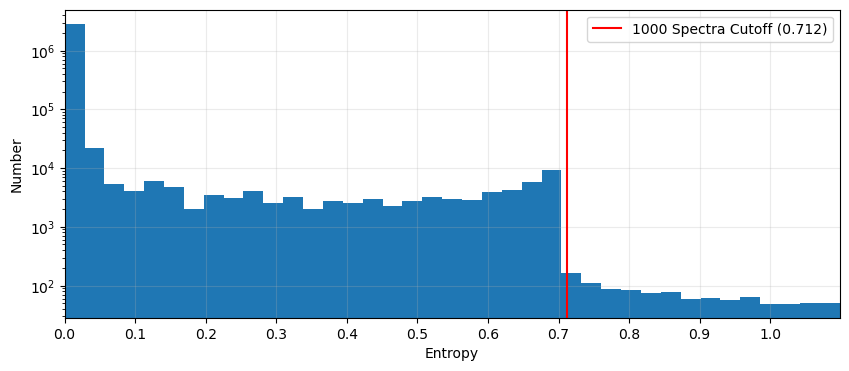

In [9]:
entropy_reduced = tbl_no_dupe["ENTROPY"][:]
bins = np.linspace(0, np.max(entropy_reduced), 40)
# bins = np.arange(0, np.max(entropy_reduced), 0.02)
print(bins)
fig, ax = plt.subplots(figsize=(10, 4))
n, bins, _ = plt.hist(entropy_reduced, bins=bins)
plt.yscale("log")

cutoff = sorted(entropy_reduced)[-1000]
plt.axvline(x = cutoff, c="r", label=f"1000 Spectra Cutoff ({np.round(cutoff, 4)})")
plt.legend()

plt.xlabel("Entropy")
plt.ylabel("Number")
print(cutoff)
plt.xlim(bins[0], bins[-1])
plt.grid(alpha=0.25)

plt.xticks(np.arange(0, np.max(entropy_reduced), 0.1))
plt.savefig("plots/entropy_dist.jpg", dpi=256, bbox_inches="tight")